# AutoEncoders

## Importing the libraries

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.optim as optim
import torch.utils.data
from torch.autograd import Variable

## Importing the dataset

In [2]:
movies = pd.read_csv('dataset/ml-1m/movies.dat', sep = '::', header = None, engine = 'python', encoding = 'latin-1')
users = pd.read_csv('dataset/ml-1m/users.dat', sep = '::', header = None, engine = 'python', encoding = 'latin-1')
ratings = pd.read_csv('dataset/ml-1m/ratings.dat', sep = '::', header = None, engine = 'python', encoding = 'latin-1')

## Preparing the training set and the test set

In [3]:
training_set = pd.read_csv('dataset/ml-100k/u1.base', delimiter = '\t')
training_set = np.array(training_set, dtype = 'int')
test_set = pd.read_csv('dataset/ml-100k/u1.test', delimiter = '\t')
test_set = np.array(test_set, dtype = 'int')

## Getting the number of users and movies

In [4]:
nb_users = int(max(max(training_set[:,0]), max(test_set[:,0])))
nb_movies = int(max(max(training_set[:,1]), max(test_set[:,1])))

## Converting the data into an array with users in lines and movies in columns

In [5]:
def convert(data):
    new_data = []
    for id_users in range(1, nb_users + 1):
        id_movies = data[:,1][data[:,0] == id_users]
        id_ratings = data[:,2][data[:,0] == id_users]
        ratings = np.zeros(nb_movies)
        ratings[id_movies - 1] = id_ratings
        new_data.append(list(ratings))
    return new_data
training_set = convert(training_set)
test_set = convert(test_set)

## Converting the data into Torch tensors

In [6]:
training_set = torch.FloatTensor(training_set)
test_set = torch.FloatTensor(test_set)

## Creating the architecture of the Neural Network

In [7]:
class SAE(nn.Module):
    def __init__(self, ):
        super(SAE, self).__init__()
        self.fc1 = nn.Linear(nb_movies, 20)
        self.fc2 = nn.Linear(20, 10)
        self.fc3 = nn.Linear(10, 20)
        self.fc4 = nn.Linear(20, nb_movies)
        self.activation = nn.Sigmoid()
    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        x = self.activation(self.fc3(x))
        x = self.fc4(x)
        return x
sae = SAE()
criterion = nn.MSELoss()
optimizer = optim.RMSprop(sae.parameters(), lr = 0.01, weight_decay = 0.5)

## Training the SAE

In [8]:
nb_epoch = 200
for epoch in range(1, nb_epoch + 1):
    train_loss = 0
    s = 0.
    for id_user in range(nb_users):
        input = Variable(training_set[id_user]).unsqueeze(0)
        target = input.clone()
        if torch.sum(target.data > 0) > 0:
            output = sae(input)
            target.require_grad = False
            output[target == 0] = 0
            loss = criterion(output, target)
            mean_corrector = nb_movies/float(torch.sum(target.data > 0) + 1e-10)
            loss.backward()
            train_loss += np.sqrt(loss.item() * mean_corrector)
            s += 1.
            optimizer.step()
    print('epoch: '+str(epoch)+' loss: '+str(train_loss/s))

epoch: 1 loss: 1.7709595628279895
epoch: 2 loss: 1.0967303501730505
epoch: 3 loss: 1.0533589179908824
epoch: 4 loss: 1.0383751792309222
epoch: 5 loss: 1.0308626012918596
epoch: 6 loss: 1.0268482449157015
epoch: 7 loss: 1.023700705998377
epoch: 8 loss: 1.021947849083783
epoch: 9 loss: 1.0207642753166404
epoch: 10 loss: 1.0195164327961315
epoch: 11 loss: 1.0188883688598545
epoch: 12 loss: 1.0182723683505843
epoch: 13 loss: 1.017896686399134
epoch: 14 loss: 1.0175020035126066
epoch: 15 loss: 1.0173695063099542
epoch: 16 loss: 1.0168880656701489
epoch: 17 loss: 1.016895850118937
epoch: 18 loss: 1.0163217001208127
epoch: 19 loss: 1.0163158294122197
epoch: 20 loss: 1.016005688482168
epoch: 21 loss: 1.0161394572459836
epoch: 22 loss: 1.0157066806888022
epoch: 23 loss: 1.015771265670107
epoch: 24 loss: 1.0156736292677153
epoch: 25 loss: 1.015740340944254
epoch: 26 loss: 1.0154095189305958
epoch: 27 loss: 1.0153168241315547
epoch: 28 loss: 1.015122404972647
epoch: 29 loss: 1.013510853186469
epo

In [9]:
nb_epoch = 200
for epoch in range(1, nb_epoch + 1):
    train_loss = 0
    s = 0.
    for id_user in range(nb_users):
        input = Variable(training_set[id_user]).unsqueeze(0)
        target = input.clone()
        if torch.sum(target.data > 0) > 0:
            output = sae(input)
            target.require_grad = False
            output[target == 0] = 0
            loss = criterion(output, target)
            mean_corrector = nb_movies/float(torch.sum(target.data > 0) + 1e-10)
            loss.backward()
            train_loss += np.sqrt(loss.item() * mean_corrector)
            s += 1.
            optimizer.step()
    print('epoch: '+str(epoch)+' loss: '+str(train_loss/s))

epoch: 1 loss: 0.9125404130170508
epoch: 2 loss: 0.9123141239334063
epoch: 3 loss: 0.9122942312996803
epoch: 4 loss: 0.9125135390833086
epoch: 5 loss: 0.9121924830385738
epoch: 6 loss: 0.9121696108236506
epoch: 7 loss: 0.9119982186137703
epoch: 8 loss: 0.9119701864529681
epoch: 9 loss: 0.9115736460265842
epoch: 10 loss: 0.9117988169978
epoch: 11 loss: 0.9113227519278918
epoch: 12 loss: 0.9113174279739968
epoch: 13 loss: 0.9109489392211211
epoch: 14 loss: 0.9108668812767489
epoch: 15 loss: 0.9107630915124645
epoch: 16 loss: 0.9111934048401725
epoch: 17 loss: 0.9105814250875498
epoch: 18 loss: 0.9108950291457627
epoch: 19 loss: 0.9104175827480107
epoch: 20 loss: 0.9105413403774427
epoch: 21 loss: 0.9098636532297212
epoch: 22 loss: 0.9102823360505107
epoch: 23 loss: 0.9095360721288807
epoch: 24 loss: 0.9097665111242971
epoch: 25 loss: 0.9093844286744714
epoch: 26 loss: 0.9097027003286471
epoch: 27 loss: 0.9089926820048388
epoch: 28 loss: 0.9094833907984546
epoch: 29 loss: 0.90908333049865

## Testing the SAE

In [10]:
test_loss = 0
s = 0.
for id_user in range(nb_users):
    input = Variable(training_set[id_user]).unsqueeze(0)
    target = Variable(test_set[id_user]).unsqueeze(0)
    if torch.sum(target.data > 0) > 0:
        output = sae(input)
        target.require_grad = False
        output[target == 0] = 0
        loss = criterion(output, target)
        mean_corrector = nb_movies/float(torch.sum(target.data > 0) + 1e-10)
        test_loss += np.sqrt(loss.item() * mean_corrector)
        s += 1.
print('test loss: '+str(test_loss/s))

test loss: 0.9532392836673391


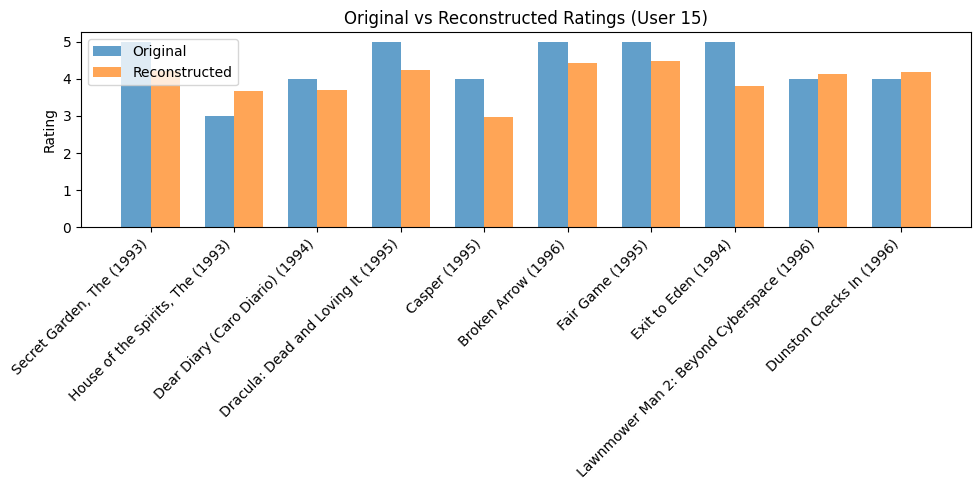

In [38]:
import matplotlib.pyplot as plt
import random

# Choose a user
user_id = 15
input_vec = Variable(training_set[user_id]).unsqueeze(0)
output_vec = sae(input_vec).detach().numpy().flatten()
original_vec = training_set[user_id].numpy()
movie_titles = {}
with open('dataset/ml-1m/movies.dat', encoding='latin-1') as f:
    for line in f:
        parts = line.strip().split("::")
        movie_id = int(parts[0])
        title = parts[1]
        movie_titles[movie_id] = title

# Only show rated movies
rated_indices = np.where(original_vec > 0)[0]
sample_indices = np.random.choice(rated_indices, size=min(10, len(rated_indices)), replace=False)

# Prepare data
movie_labels = [movie_titles[i + 1] for i in sample_indices]  # +1 for 0-based index
original_ratings = original_vec[sample_indices]
predicted_ratings = output_vec[sample_indices]

# Plot
x = np.arange(len(sample_indices))
bar_width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x, original_ratings, width=bar_width, label='Original', alpha=0.7)
plt.bar(x + bar_width, predicted_ratings, width=bar_width, label='Reconstructed', alpha=0.7)
plt.xticks(x + bar_width / 2, movie_labels, rotation=45, ha='right')
plt.ylabel("Rating")
plt.title(f"Original vs Reconstructed Ratings (User {user_id})")
plt.legend()
plt.tight_layout()
plt.show()
